In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Import models from scikit learn module:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ML Workflow

- Data Acquisition/Loading
- Initial EDA
- Data cleaning and preprocessing (feature data type, mapping, duplicated values, null values, outlier).
- Deeper EDA- summary statistic and visualisation
- Train-Test Split
- Data/Feature transformation (fit on train, transform on test) e.g. numerical transformation e.g. binning, scaling e.g. standardisation or normalisation, categorical/non-numerical encoding e.g. mapping, one-hot coding
- Feature selection (filter method e.g. collinearity, wrapper method, embedded method)
- Dimensionality reduction **(if necessary)**
- Model selection/building (on train dataset)
- Hyperparameter tuning (on validation dataset), e.g. grid search or random search
- Model Evaluation

# 1.0 Data Acquisition and Loading

In [4]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
census_income = fetch_ucirepo(id=20) 
  
# data (as pandas dataframes) 
X = census_income.data.features 
y = census_income.data.targets 
  
# metadata 
print(census_income.metadata) 
  
# variable information 
print(census_income.variables) 


{'uci_id': 20, 'name': 'Census Income', 'repository_url': 'https://archive.ics.uci.edu/dataset/20/census+income', 'data_url': 'https://archive.ics.uci.edu/static/public/20/data.csv', 'abstract': 'Predict whether income exceeds $50K/yr based on census data.  Also known as Adult dataset.', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Mon Sep 09 2024', 'dataset_doi': '10.24432/C5GP7S', 'creators': ['Ron Kohavi'], 'intro_paper': None, 'additional_info': {'summary': 'Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the following conditions: ((AAGE>16) && 

### Metadata

Census Income
- UCI ID: 20
- Task: Classification
- Instances: 48,842
- Features: 14
- Feature Types: Categorical, Integer
- Target Column: income
- Missing Values: Yes (NaN)
- Dataset Created: 1996
- Last Updated: September 9, 2024
- DOI: 10.24432/C5GP7S
- Creator: Ron Kohavi
- Area: Social Science
- Characteristics: Multivariate
- Demographics: Age, income, education level, race, sex, and other attributes
- Repository: UCI Census Income dataset
- Data: CSV download

**Overview**

Predict whether an individual's annual income exceeds $50K using census data. 

This dataset is also known as the Adult dataset.
Barry Becker extracted the data from the 1994 Census database, retaining relatively clean records under these conditions: 
**(AAGE > 16) && (AGI > 100) && (AFNLWGT > 1) && (HRSWK > 0)**

The prediction target is whether a person earns >50K or <=50K per year.

**Variables**

Variable	Description / Values

- age	Continuous
- workclass	Private, self-employed, government, unpaid, never worked, and related categories
- fnlwgt	Continuous final sampling weight
- education	Educational attainment, such as Bachelors, HS-grad, Masters, Doctorate, and others
- education-num	Continuous numeric education level
- marital-status	Marital-status categories
- occupation	Occupation categories, such as Tech-support, Sales, Exec-managerial, Prof-specialty, and others
- relationship	Household relationship, such as Wife, Husband, Own-child, Not-in-family, and others
- race	White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black
- sex	Female, Male
- capital-gain	Continuous
- capital-loss	Continuous
- hours-per-week	Continuous
- native-country	Country of origin, including United-States, Canada, Mexico, India, and others
- income	Target: >50K or <=50K

# Preliminary EDA

In [8]:
y.head()

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


In [9]:
y.value_counts()

income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

In [10]:
map = {">50K":1, ">50K.":1, "<=50K":0, "<=50K.":0}
y = y.replace(map)
y.value_counts()

C:\Users\emper\AppData\Local\Temp\ipykernel_22176\1754416969.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace(map)


income
0         37155
1         11687
Name: count, dtype: int64

The target variable has class imbalance in favour of the <=50K class

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [13]:
df = pd.concat([X,y], axis = 1)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [14]:
df.describe(include = "all")

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,48842.000000,47879,4.884200e+04,48842,48842.000000,48842,47876,48842,48842,48842,48842.000000,48842.000000,48842.000000,48568,48842.000000
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,NaN
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,NaN
freq,NaN,33906,NaN,15784,NaN,22379,6172,19716,41762,32650,NaN,NaN,NaN,43832,NaN
mean,38.643585,NaN,1.896641e+05,NaN,10.078089,NaN,NaN,NaN,NaN,NaN,1079.067626,87.502314,40.422382,NaN,0.239282
std,13.710510,NaN,1.056040e+05,NaN,2.570973,NaN,NaN,NaN,NaN,NaN,7452.019058,403.004552,12.391444,NaN,0.426649
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,0.000000
25%,28.000000,NaN,1.175505e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,0.000000
50%,37.000000,NaN,1.781445e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,0.000000
75%,48.000000,NaN,2.376420e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,0.000000


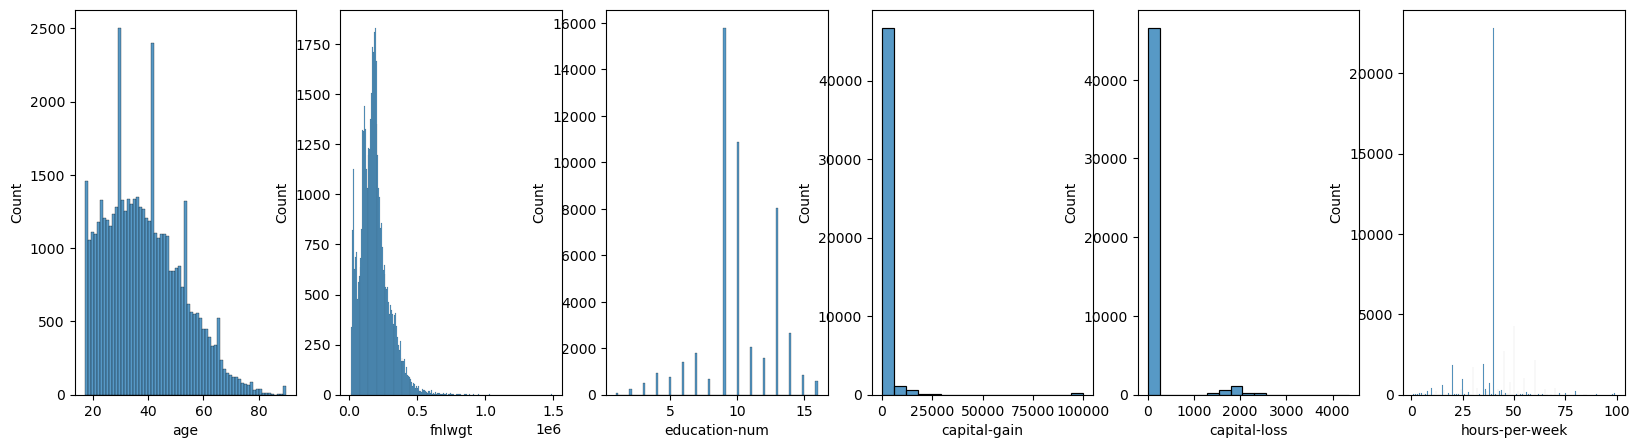

In [15]:
fig, ax = plt.subplots(1,6,figsize=(20,5))
sns.histplot(df.age, ax=ax[0])
sns.histplot(df.fnlwgt, ax=ax[1])
sns.histplot(df["education-num"], ax=ax[2])
sns.histplot(df["capital-gain"], ax=ax[3])
sns.histplot(df["capital-loss"], ax=ax[4])
sns.histplot(df["hours-per-week"], ax=ax[5])
plt.show()

# Preprocessing

### Treating Missing Values

In [18]:
df["native-country"].value_counts()

native-country
United-States                 43832
Mexico                          951
?                               583
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

In [19]:
# Replace ? with NA values
df.replace('?', pd.NA, inplace=True)
df["native-country"].value_counts()

native-country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru                             46
Ecuador      

### Label Missing Values as "Not_Reported"

In [21]:
df["native-country"] = df["native-country"].apply(
    lambda x: (
        "Not_Reported"
        if pd.isna(x)
        else x
        if x in ["United-States", "Mexico"]
        else "Others"
    )
)

print(df["native-country"].value_counts())

native-country
United-States    43832
Others            3202
Mexico             951
Not_Reported       857
Name: count, dtype: int64


In [22]:
df["occupation"].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [23]:
def group_occupation(occ):
    if pd.isna(occ):
        return "Not Reported"
    elif occ in [
        "Prof-specialty",
        "Exec-managerial",
        "Craft-repair",
        "Tech-support",
        "Adm-clerical"
    ]:
        return "Skilled"
    else:
        return "Non-skilled"

df["occupation_group"] = df["occupation"].apply(group_occupation)

# Check the result
print(df["occupation_group"].value_counts())

occupation_group
Skilled         25427
Non-skilled     20606
Not Reported     2809
Name: count, dtype: int64


In [24]:
df["workclass"].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [25]:
def classify_workclass(workclass):
    if pd.isna(workclass):
        return "Not Reported"
    elif workclass == "Private":
        return "Private"
    elif workclass in [
        "Federal-gov",
        "State-gov",
        "Local-gov"
    ]:
        return "Government"
    else:
        return "Others"

df["workclass_group"] = df["workclass"].apply(classify_workclass)

# Verify the result
print(df["workclass_group"].value_counts())

workclass_group
Private         33906
Government       6549
Others           5588
Not Reported     2799
Name: count, dtype: int64


In [26]:
df["education"].value_counts()

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

In [27]:
college = [
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]

df["education_group"] = df["education"].apply(
    lambda x: "College Educated" if x in college else "Non-College"
)

print(df["education_group"].value_counts())

education_group
Non-College         33070
College Educated    15772
Name: count, dtype: int64


# Deeper EDA

### Bivariate EDA

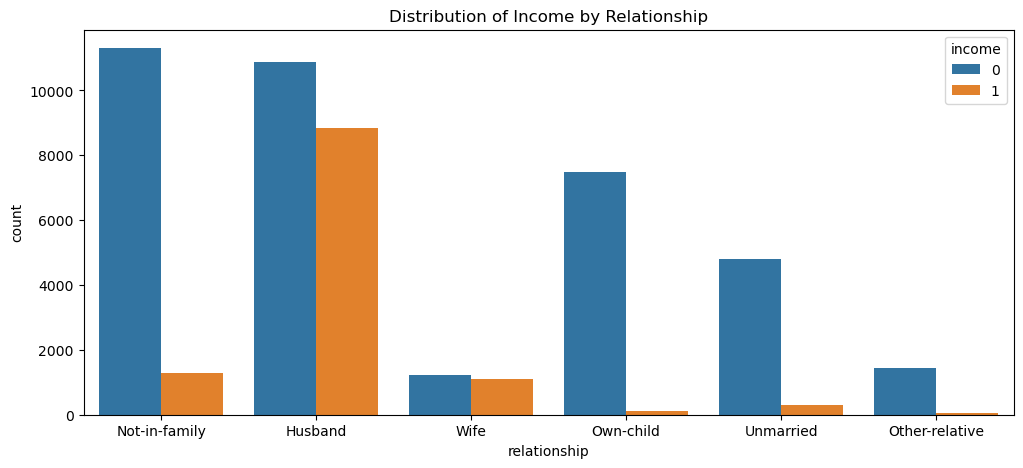

In [29]:
fig = plt.figure(figsize=(12,5))
sns.countplot(data= df, x="relationship", hue= "income")
plt.title("Distribution of Income by Relationship")
plt.show()

In [30]:
df.groupby(["education_group", "income"]).size()

education_group   income
College Educated  0          9017
                  1          6755
Non-College       0         28138
                  1          4932
dtype: int64

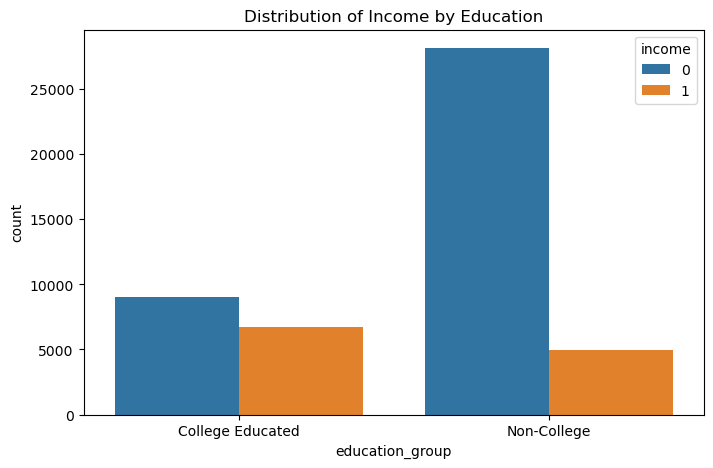

In [31]:
fig = plt.figure(figsize=(8,5))
sns.countplot(data= df, x="education_group", hue= "income")
plt.title("Distribution of Income by Education")
plt.show()

In [32]:
df.groupby(["workclass_group", "income"]).size()

workclass_group  income
Government       0          4531
                 1          2018
Not Reported     0          2534
                 1           265
Others           0          3571
                 1          2017
Private          0         26519
                 1          7387
dtype: int64

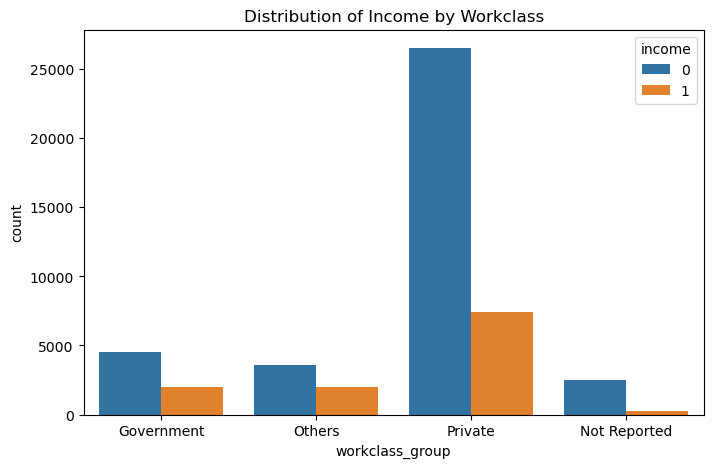

In [33]:
fig = plt.figure(figsize=(8,5))
sns.countplot(data= df, x="workclass_group", hue= "income")
plt.title("Distribution of Income by Workclass")
plt.show()

In [34]:
df.groupby(["occupation_group", "income"]).size()

occupation_group  income
Non-skilled       0         17447
                  1          3159
Not Reported      0          2544
                  1           265
Skilled           0         17164
                  1          8263
dtype: int64

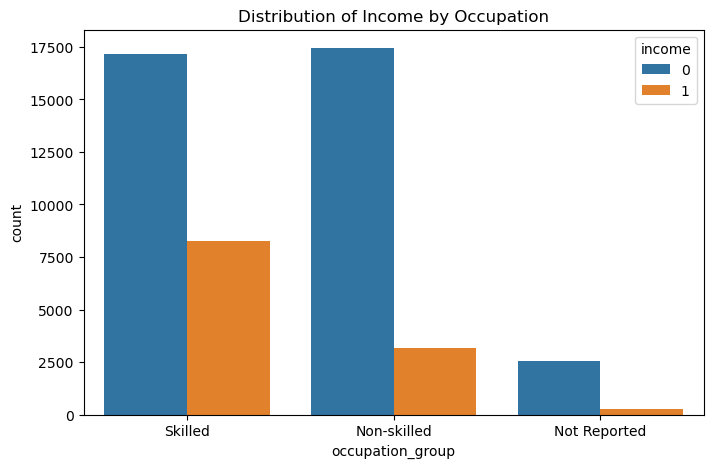

In [35]:
fig = plt.figure(figsize=(8,5))
sns.countplot(data= df, x="occupation_group", hue= "income")
plt.title("Distribution of Income by Occupation")
plt.show()

In [36]:
df.groupby(["race", "income"]).size()

race                income
Amer-Indian-Eskimo  0           415
                    1            55
Asian-Pac-Islander  0          1110
                    1           409
Black               0          4119
                    1           566
Other               0           356
                    1            50
White               0         31155
                    1         10607
dtype: int64

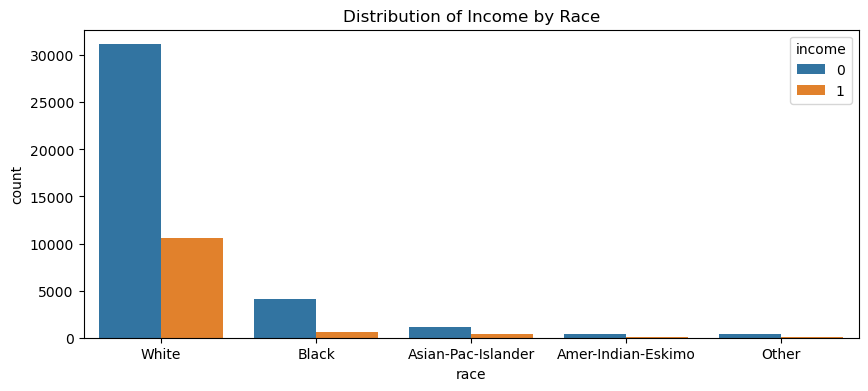

In [37]:
fig = plt.figure(figsize=(10,4))
sns.countplot(data= df, x="race", hue = "income" )
plt.title("Distribution of Income by Race")
plt.show()

The distribution of income by race shows that white people enjoy absolate domination over the people of colour across the two categories of income earners. The black people also appear to have significant domination over other people of colour. This is perhaps, a reflection of population distribution of the United State across races. 

In [39]:
df.groupby(["sex", "income"]).size()

sex     income
Female  0         14423
        1          1769
Male    0         22732
        1          9918
dtype: int64

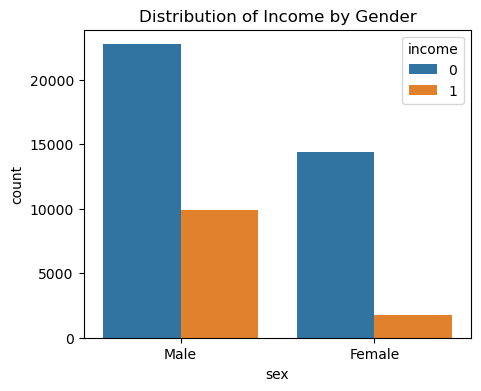

In [40]:
fig = plt.figure(figsize=(5,4))
sns.countplot(data= df, x="sex", hue = "income" )
plt.title("Distribution of Income by Gender")
plt.show()

The distribution of income by gender shows male domination across the two categories of earners. This reveals a serious ethical concern of male domination of female with respect to earning power.  

In [42]:
df.groupby(["native-country", "income"]).size()

native-country  income
Mexico          0           904
                1            47
Not_Reported    0           637
                1           220
Others          0          2476
                1           726
United-States   0         33138
                1         10694
dtype: int64

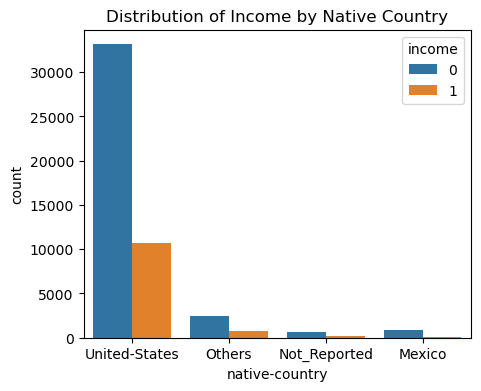

In [43]:
fig = plt.figure(figsize=(5,4))
sns.countplot(data= df, x="native-country", hue = "income" )
plt.title("Distribution of Income by Native Country")
plt.show()

### Multivariate EDA

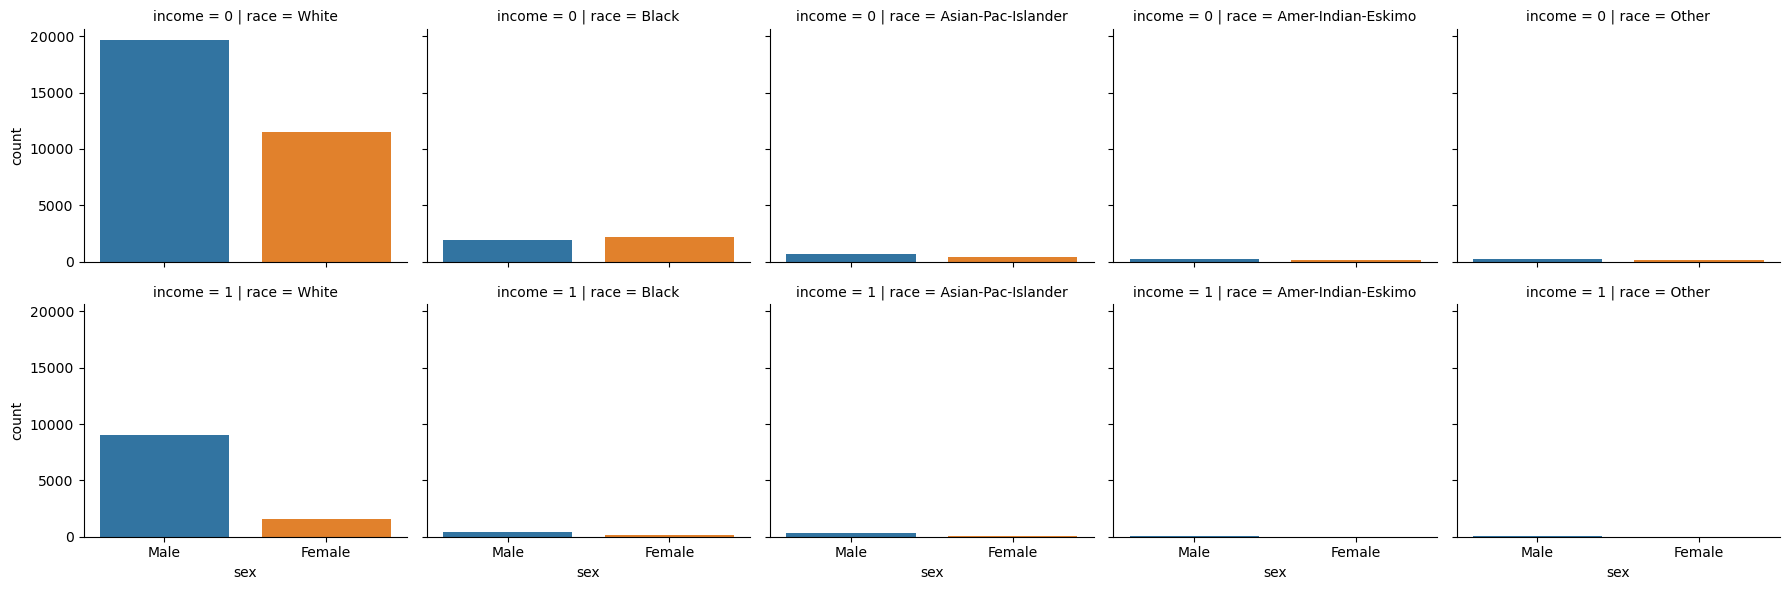

In [264]:
sns.catplot(
    data=df,
    x="sex",
    hue="sex",
    col="race",
    row="income",
    kind="count",
    height=3,
    aspect=1.2)
plt.show()

The chart above confirm male gender domination across all races and income categories. Interestingly, within the black race, the number of female earning less that 50K is slighly more than the number of male earning the same amount while the number of male earning about 50K almost doubles the number of female within the same category. 

# 2.0 Data Cleaning and Preprocessing

In [45]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,occupation_group,workclass_group,education_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0,Skilled,Government,College Educated
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0,Skilled,Others,College Educated
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0,Non-skilled,Private,Non-College
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0,Non-skilled,Private,Non-College
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Others,0,Skilled,Private,College Educated


### Treating the Missing Values

In [47]:
df.isna().sum()

age                    0
workclass           2799
fnlwgt                 0
education              0
education-num          0
marital-status         0
occupation          2809
relationship           0
race                   0
sex                    0
capital-gain           0
capital-loss           0
hours-per-week         0
native-country         0
income                 0
occupation_group       0
workclass_group        0
education_group        0
dtype: int64

workclass (963), occupation (966) and native country (274) all have missing data. The workclass and occupation will be dropped because their missing values have been treated in the workclass_group and education_group respectively,         

### Use X to Justify the Missing Value Treatment

In [50]:
X.isna().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
dtype: int64

In [51]:
# Start with the native-country
# Check the native-country distribution
X["native-country"].value_counts()

native-country
United-States                 43832
Mexico                          951
?                               583
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Greece                           49
Nicaragua                        49
Peru         

The missing value here is represented by ? (a question mark) which could mean that the missingness is due to data entry gaps. However, it is important to check if the missingness is linked to the target value

In [53]:
X.replace('?', pd.NA, inplace=True)

C:\Users\emper\AppData\Local\Temp\ipykernel_22176\3602955208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace('?', pd.NA, inplace=True)


In [54]:
X.workclass.value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [55]:
X.occupation.value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [56]:
X.workclass.value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

### Do Workclass and Occupation Go Missing Together?

In [58]:
both_missing = X['workclass'].isna() & X['occupation'].isna()
only_workclass = X['workclass'].isna() & X['occupation'].notna()
only_occupation = X['workclass'].notna() & X['occupation'].isna()

print(f"Both missing: {both_missing.sum()}")
print(f"Only workclass missing: {only_workclass.sum()}")
print(f"Only occupation missing: {only_occupation.sum()}")

Both missing: 2799
Only workclass missing: 0
Only occupation missing: 10


In [59]:
# Check the missing values in occupation against the non missing values in workclass
X2 = X[X['workclass'].notna() & X['occupation'].isna()]
X2

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
5361,18,Never-worked,206359,10th,6,Never-married,<NA>,Own-child,White,Male,0,0,40,United-States
10845,23,Never-worked,188535,7th-8th,4,Divorced,<NA>,Not-in-family,White,Male,0,0,35,United-States
14772,17,Never-worked,237272,10th,6,Never-married,<NA>,Own-child,White,Male,0,0,30,United-States
20337,18,Never-worked,157131,11th,7,Never-married,<NA>,Own-child,White,Female,0,0,10,United-States
23232,20,Never-worked,462294,Some-college,10,Never-married,<NA>,Own-child,Black,Male,0,0,40,United-States
32304,30,Never-worked,176673,HS-grad,9,Married-civ-spouse,<NA>,Wife,Black,Female,0,0,40,United-States
32314,18,Never-worked,153663,Some-college,10,Never-married,<NA>,Own-child,White,Male,0,0,4,United-States
41346,17,Never-worked,131593,11th,7,Never-married,NaN,Own-child,Black,Female,0,0,20,United-States
44168,20,Never-worked,273905,HS-grad,9,Married-spouse-absent,NaN,Other-relative,White,Male,0,0,35,United-States
46459,18,Never-worked,162908,11th,7,Never-married,NaN,Own-child,White,Male,0,0,35,United-States


The missingness in the workclass and occupation are somewhat structurally related as 2799 records are missing in both. Also the 10 records that are only missing in the occupation were those who belong to the Never-work category of the workclass. This could perhaps be a pointer to the fact that the missingness is being driven by the employment status. This justify the earlier coding of the missing values in workclass and occupation as "Not-Reported" in the workclass_group and occupation_group columns. 

### Treating Duplicated Values

In [62]:
df.duplicated().sum()

52

In [63]:
# Remove the duplicated values
df = df.drop_duplicates(keep = "first", inplace=False)
df.duplicated().sum()

0

In [64]:
df.isna().sum()

age                    0
workclass           2795
fnlwgt                 0
education              0
education-num          0
marital-status         0
occupation          2805
relationship           0
race                   0
sex                    0
capital-gain           0
capital-loss           0
hours-per-week         0
native-country         0
income                 0
occupation_group       0
workclass_group        0
education_group        0
dtype: int64

### Deal with the Numerical Feature

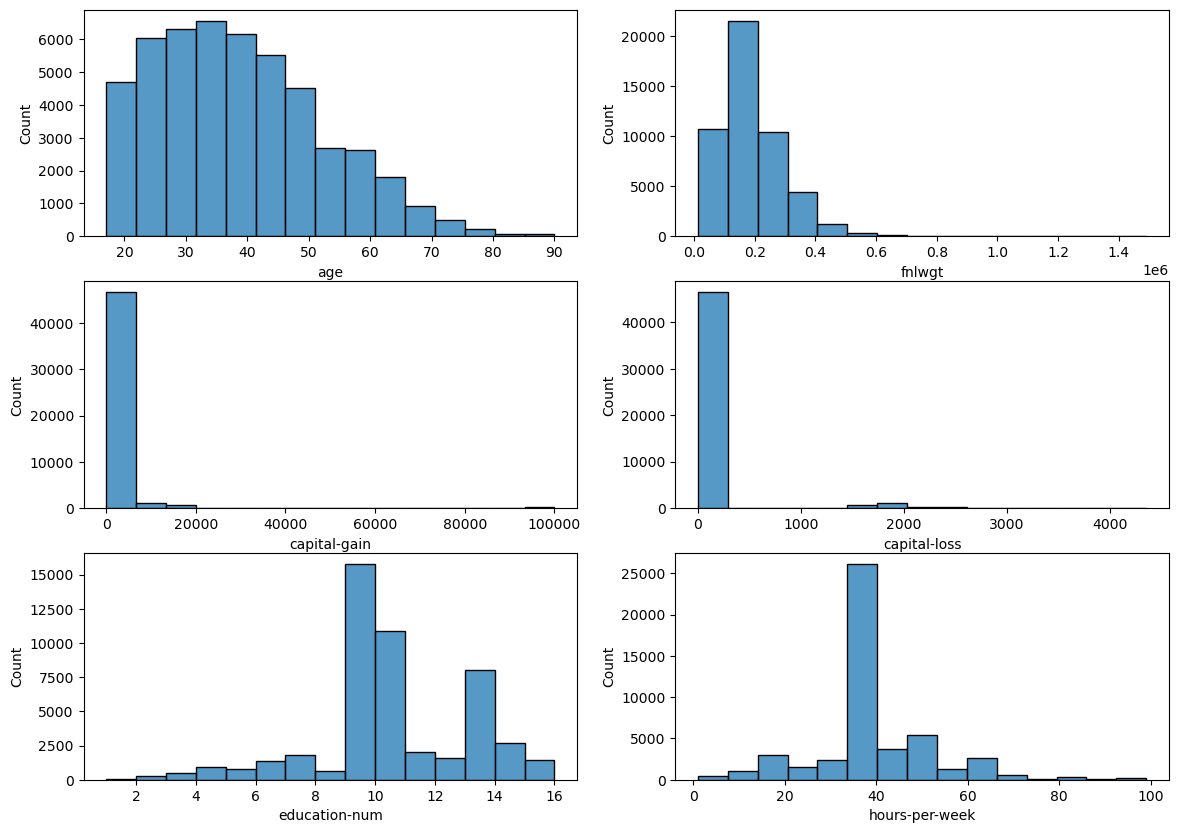

In [66]:
# Plot the histogram
fig, ax = plt.subplots(3,2, figsize=(14,10))
sns.histplot(data = df, x= "age", bins = 15, ax=ax[0,0])
sns.histplot(data = df, x= "fnlwgt", bins = 15, ax=ax[0,1])
sns.histplot(data = df, x= "capital-gain", bins = 15, ax=ax[1,0])
sns.histplot(data = df, x= "capital-loss", bins = 15, ax=ax[1,1])
sns.histplot(df["education-num"], bins =15, ax=ax[2, 0])
sns.histplot(df["hours-per-week"], bins =15, ax=ax[2,1])
plt.show()

In [67]:
df.isna().sum()

age                    0
workclass           2795
fnlwgt                 0
education              0
education-num          0
marital-status         0
occupation          2805
relationship           0
race                   0
sex                    0
capital-gain           0
capital-loss           0
hours-per-week         0
native-country         0
income                 0
occupation_group       0
workclass_group        0
education_group        0
dtype: int64

# Feature Engineering

In [69]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,occupation_group,workclass_group,education_group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0,Skilled,Government,College Educated
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0,Skilled,Others,College Educated
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0,Non-skilled,Private,Non-College
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0,Non-skilled,Private,Non-College
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Others,0,Skilled,Private,College Educated


### More Categorical Encoding

In [71]:
df["marital_status_grouped"] = df["marital-status"].replace({
    "Married-civ-spouse": "Married",
    "Married-spouse-absent": "Married",
    "Married-AF-spouse": "Married",
    "Never-married": "Never-married",
    "Divorced": "Previously-married",
    "Separated": "Previously-married",
    "Widowed": "Previously-married"
})
df["marital_status_grouped"].value_counts()

marital_status_grouped
Married               23030
Never-married         16082
Previously-married     9678
Name: count, dtype: int64

In [72]:
df["relationship_grouped"] = df["relationship"].replace({
    "Husband": "Family",
    "Wife": "Family",
    "Own-child": "Family",
    "Other-relative": "Family",
    "Not-in-family": "Independent",
    "Unmarried": "Independent"
})
df["relationship_grouped"].value_counts()

relationship_grouped
Family         31109
Independent    17681
Name: count, dtype: int64

In [73]:
df["race_grouped"] = df["race"].replace({
    "White": "White",
    "Black": "Non-White",
    "Asian-Pac-Islander": "Non-White",
    "Amer-Indian-Eskimo": "Non-White",
    "Other": "Non-White"
})
df["race_grouped"].value_counts()

race_grouped
White        41714
Non-White     7076
Name: count, dtype: int64

In [74]:
df2 = df.drop(columns = ["workclass", "occupation", "education", "marital-status","relationship", "race"]).reset_index()
df2.head()

,index,age,fnlwgt,education-num,sex,capital-gain,capital-loss,hours-per-week,native-country,income,occupation_group,workclass_group,education_group,marital_status_grouped,relationship_grouped,race_grouped
0,0,39,77516,13,Male,2174,0,40,United-States,0,Skilled,Government,College Educated,Never-married,Independent,White
1,1,50,83311,13,Male,0,0,13,United-States,0,Skilled,Others,College Educated,Married,Family,White
2,2,38,215646,9,Male,0,0,40,United-States,0,Non-skilled,Private,Non-College,Previously-married,Independent,White
3,3,53,234721,7,Male,0,0,40,United-States,0,Non-skilled,Private,Non-College,Married,Family,Non-White
4,4,28,338409,13,Female,0,0,40,Others,0,Skilled,Private,College Educated,Married,Family,Non-White


In [75]:
df2.head()
df2 = pd.get_dummies(df2, columns= ["sex", "native-country", "occupation_group", "workclass_group", "education_group",
                                   "marital_status_grouped", "relationship_grouped", "race_grouped"], drop_first = True)
df2.head()

,index,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,sex_Male,native-country_Not_Reported,...,occupation_group_Not Reported,occupation_group_Skilled,workclass_group_Not Reported,workclass_group_Others,workclass_group_Private,education_group_Non-College,marital_status_grouped_Never-married,marital_status_grouped_Previously-married,relationship_grouped_Independent,race_grouped_White
0,0,39,77516,13,2174,0,40,0,True,False,...,False,True,False,False,False,False,True,False,True,True
1,1,50,83311,13,0,0,13,0,True,False,...,False,True,False,True,False,False,False,False,False,True
2,2,38,215646,9,0,0,40,0,True,False,...,False,False,False,False,True,True,False,True,True,True
3,3,53,234721,7,0,0,40,0,True,False,...,False,False,False,False,True,True,False,False,False,False
4,4,28,338409,13,0,0,40,0,False,False,...,False,True,False,False,True,False,False,False,False,False


### Split the Data into x and y

In [77]:
x = df2.drop(columns = {"index", "income"})
y= df2["income"]

In [78]:
correlation = x.corr()
correlation

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,sex_Male,native-country_Not_Reported,native-country_Others,native-country_United-States,occupation_group_Not Reported,occupation_group_Skilled,workclass_group_Not Reported,workclass_group_Others,workclass_group_Private,education_group_Non-College,marital_status_grouped_Never-married,marital_status_grouped_Previously-married,relationship_grouped_Independent,race_grouped_White
age,1.000000,-0.076451,0.030635,0.077185,0.056838,0.071223,0.088043,0.001266,0.013595,0.011339,0.025968,0.075769,0.027218,0.178036,-0.191256,-0.081793,-0.538004,0.236205,0.018264,0.032364
fnlwgt,-0.076451,1.000000,-0.038727,-0.003715,-0.004378,-0.013521,0.027879,0.005036,0.013243,-0.070326,-0.005412,-0.006909,-0.005633,-0.044347,0.042950,0.021822,0.038264,-0.016479,0.006802,-0.063810
education-num,0.030635,-0.038727,1.000000,0.125219,0.080986,0.143915,0.009364,0.031681,-0.020076,0.103385,-0.080342,0.339328,-0.079592,0.059080,-0.118551,-0.791633,-0.028593,-0.058232,0.014212,0.049410
capital-gain,0.077185,-0.003715,0.125219,1.000000,-0.031475,0.082152,0.047127,0.012094,-0.004555,0.004131,-0.019158,0.062803,-0.019062,0.082485,-0.036936,-0.110774,-0.065363,-0.023324,-0.039597,0.014835
capital-loss,0.056838,-0.004378,0.080986,-0.031475,1.000000,0.054431,0.045517,0.002451,-0.002183,0.009362,-0.012315,0.046018,-0.012144,0.034583,-0.025089,-0.074181,-0.058001,-0.024026,-0.036258,0.020624
hours-per-week,0.071223,-0.013521,0.143915,0.082152,0.054431,1.000000,0.228529,0.006556,-0.007620,0.004634,-0.172172,0.113356,-0.171641,0.150187,-0.018054,-0.133099,-0.199769,-0.029828,-0.017530,0.046680
sex_Male,0.088043,0.027879,0.009364,0.047127,0.045517,0.228529,1.000000,0.011872,-0.010095,-0.011063,-0.063969,-0.018719,-0.064136,0.137009,-0.033817,-0.027974,-0.173392,-0.322555,-0.355586,0.101261
native-country_Not_Reported,0.001266,0.005036,0.031681,0.012094,0.002451,0.006556,0.011872,1.000000,-0.035398,-0.395562,-0.002155,0.002927,-0.002040,0.008333,0.001335,-0.038237,0.005927,-0.021452,0.000908,-0.070427
native-country_Others,0.013595,0.013243,-0.020076,-0.004555,-0.002183,-0.007620,-0.010095,-0.035398,1.000000,-0.784092,-0.003171,-0.005867,-0.002943,-0.001367,0.022085,-0.027058,-0.009238,-0.019219,-0.002805,-0.214471
native-country_United-States,0.011339,-0.070326,0.103385,0.004131,0.009362,0.004634,-0.011063,-0.395562,-0.784092,1.000000,0.005326,0.035442,0.005037,0.008539,-0.041130,0.004592,0.003368,0.038886,0.008047,0.194670


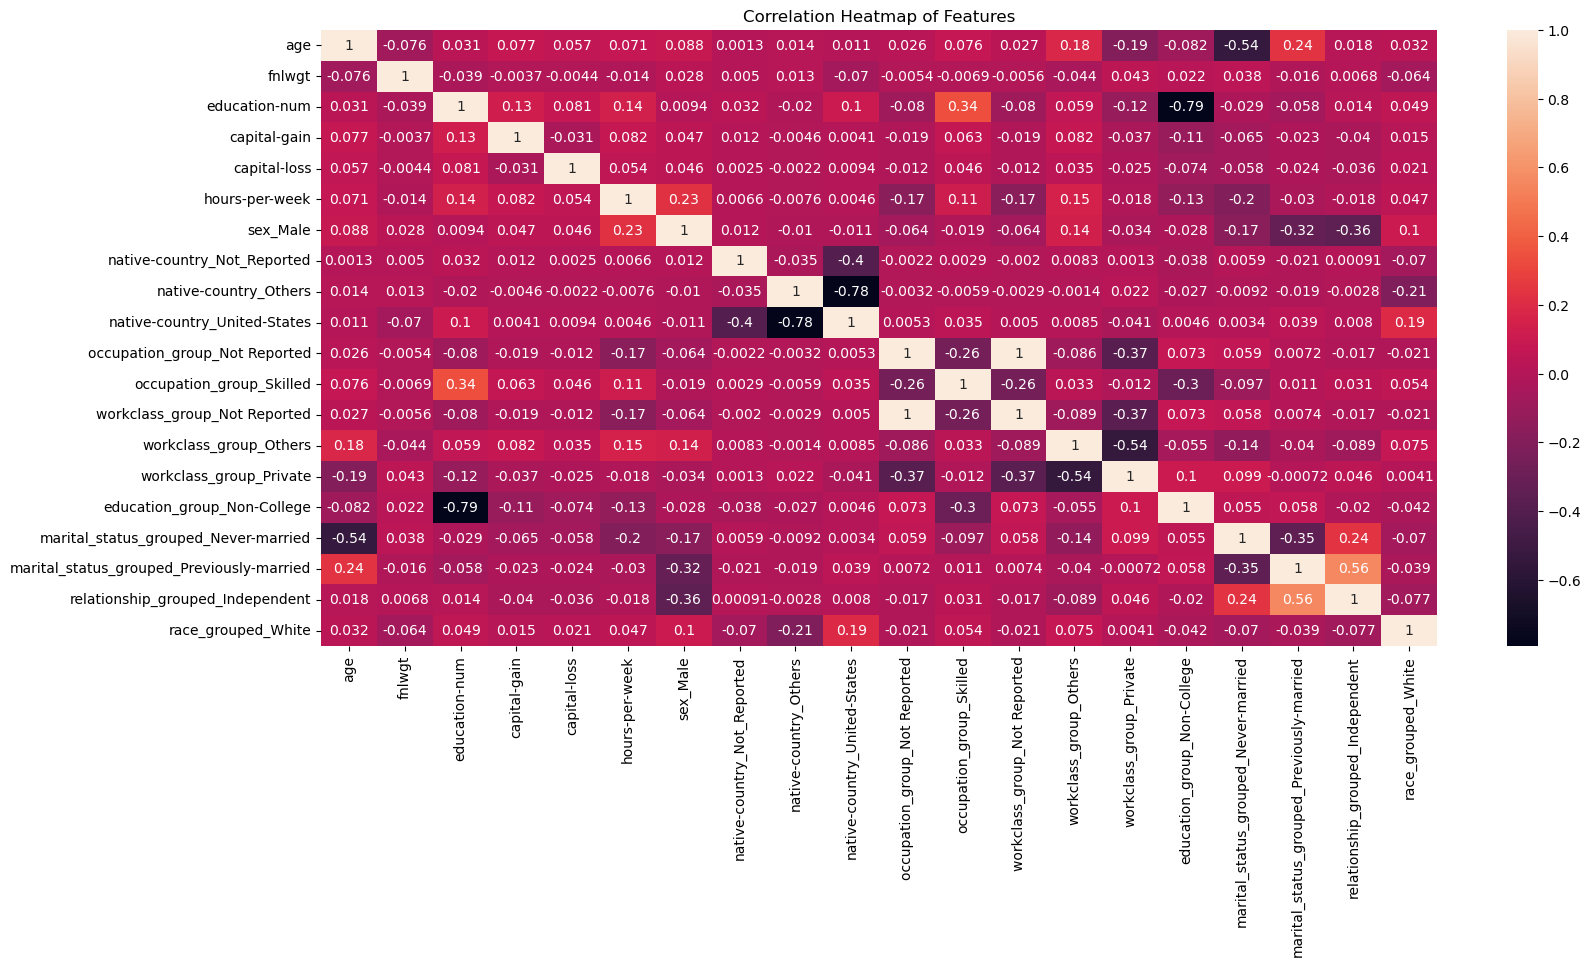

In [79]:
fig = plt.figure(figsize=(18,8))
sns.heatmap(correlation, annot = True)
plt.title("Correlation Heatmap of Features")
plt.show()

The correlation heatmap shows that education-num and education_group_Non-College have strong negative correlation (-79). Similarly, a strong negative correlation is also observed between native-country-Others and native-country_United-States. Other fearures shows a blend of moderate and low positive and weak correlations. Because, logistic regression is part of the models that will be used in this project, one of education-num and education_group_Non-College and native-country-Others and native-country_United-States will be dropped due to collinearity and redundant predictive power. Both native-country-Others and education_group_Non-College would be dropped because they were derived feature to preserve the organic predictive features of the retained features

In [81]:
df2 = df2.drop(columns = ["native-country_Others", "education_group_Non-College"]).reset_index()
df2.head()

,level_0,index,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,sex_Male,...,native-country_United-States,occupation_group_Not Reported,occupation_group_Skilled,workclass_group_Not Reported,workclass_group_Others,workclass_group_Private,marital_status_grouped_Never-married,marital_status_grouped_Previously-married,relationship_grouped_Independent,race_grouped_White
0,0,0,39,77516,13,2174,0,40,0,True,...,True,False,True,False,False,False,True,False,True,True
1,1,1,50,83311,13,0,0,13,0,True,...,True,False,True,False,True,False,False,False,False,True
2,2,2,38,215646,9,0,0,40,0,True,...,True,False,False,False,False,True,False,True,True,True
3,3,3,53,234721,7,0,0,40,0,True,...,True,False,False,False,False,True,False,False,False,False
4,4,4,28,338409,13,0,0,40,0,False,...,False,False,True,False,False,True,False,False,False,False


In [82]:
x = df2.drop(columns = {"level_0", "index", "income"})
y= df2["income"]
x.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,sex_Male,native-country_Not_Reported,native-country_United-States,occupation_group_Not Reported,occupation_group_Skilled,workclass_group_Not Reported,workclass_group_Others,workclass_group_Private,marital_status_grouped_Never-married,marital_status_grouped_Previously-married,relationship_grouped_Independent,race_grouped_White
0,39,77516,13,2174,0,40,True,False,True,False,True,False,False,False,True,False,True,True
1,50,83311,13,0,0,13,True,False,True,False,True,False,True,False,False,False,False,True
2,38,215646,9,0,0,40,True,False,True,False,False,False,False,True,False,True,True,True
3,53,234721,7,0,0,40,True,False,True,False,False,False,False,True,False,False,False,False
4,28,338409,13,0,0,40,False,False,False,False,True,False,False,True,False,False,False,False


### Split the Data into Train and Test Dataset

In [84]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, stratify = y, random_state = 100)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((34153, 18), (14637, 18), (34153,), (14637,))

### Standardise  the Dataset

In [86]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_train_scaled
x_test_scaled = scaler.transform(x_test)
x_test_scaled

array([[ 0.03055949, -0.29664879, -0.03311785, ..., -0.49585154,
        -0.75238067,  0.41301987],
       [ 0.83497951, -1.5959451 , -0.03311785, ...,  2.01673268,
         1.32911443, -2.42119102],
       [ 1.27375406, -0.2797245 , -1.59268201, ...,  2.01673268,
         1.32911443,  0.41301987],
       ...,
       [-0.11569869, -0.4434394 , -1.59268201, ..., -0.49585154,
        -0.75238067,  0.41301987],
       [-0.48134415,  0.44210469, -0.03311785, ...,  2.01673268,
         1.32911443,  0.41301987],
       [ 0.39620495,  0.77270958, -0.42300889, ..., -0.49585154,
        -0.75238067, -2.42119102]])

# Build the ML Models

### Start with a Dummy Model

In [89]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV
dummy_model = DummyClassifier(strategy = "most_frequent", random_state=100)
dummy_model.fit(x_train_scaled, y_train)
dummy_y_test_pred = dummy_model.predict(x_test_scaled)
dm_precision = precision_score(y_test, dummy_y_test_pred)
dm_recall = recall_score(y_test, dummy_y_test_pred)
dm_f1 = f1_score(y_test, dummy_y_test_pred)
dm_roc_auc = roc_auc_score(y_test, dummy_y_test_pred)
dm_acc = dummy_model.score(x_test_scaled, y_test)
print("accuracy: ", dm_acc)
print("dm_precision: ", dm_precision)
print("dm_recall: ", dm_recall)
print("dm_f1: ", dm_f1)
print("dm_roc_auc: ", dm_roc_auc)
cm = confusion_matrix(y_test, dummy_y_test_pred)
cm

accuracy:  0.760606681697069
dm_precision:  0.0
dm_recall:  0.0
dm_f1:  0.0
dm_roc_auc:  0.5


C:\Users\emper\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[11133,     0],
       [ 3504,     0]], dtype=int64)

### Logistic Regression

In [91]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(solver="liblinear",random_state=100)
print(lr.get_params())
lr.fit(x_train_scaled, y_train)
lr_accuracy = lr.score(x_test_scaled, y_test)
print("accuracy: ", lr_accuracy)

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'auto', 'n_jobs': None, 'penalty': 'l2', 'random_state': 100, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
accuracy:  0.8418391746942679


In [92]:
lr_parameters = {"penalty": ["l1", "l2"],  "C": [0.1, 1, 10]}
# C values of 0.1, 1, and 10 represents strong, moderate and weak regularisation respectively
lr_grid = GridSearchCV(lr, lr_parameters)
lr_grid.fit(x_train_scaled, y_train)
print("best parameters are ", lr_grid.best_params_)
print("best model is ", lr_grid.best_estimator_)
print("best score is ", lr_grid.best_score_)

best parameters are  {'C': 1, 'penalty': 'l1'}
best model is  LogisticRegression(C=1, penalty='l1', random_state=100, solver='liblinear')
best score is  0.8453135209758802


In [93]:
lr_y_test_pred = lr_grid.predict(x_test_scaled)
lr_grid_accuracy = lr_grid.score(x_test_scaled, y_test)
lr_grid_precision = precision_score(y_test, lr_y_test_pred)
lr_grid_recall = recall_score(y_test, lr_y_test_pred)
lr_grid_f1_score = f1_score(y_test, lr_y_test_pred)
lr_roc_auc = roc_auc_score(y_test, lr_y_test_pred)
print("lr_grid_accuracy: ", lr_grid_accuracy)
print("lr_grid_precision: ", lr_grid_precision)
print("lr_grid_recall: ", lr_grid_recall)
print("lr_grid_f1_score: ", lr_grid_f1_score)
print("lr_roc_auc: ", lr_roc_auc)
lr_cm = confusion_matrix(y_test, lr_y_test_pred)
lr_cm

lr_grid_accuracy:  0.8418391746942679
lr_grid_precision:  0.720757519494987
lr_grid_recall:  0.5539383561643836
lr_grid_f1_score:  0.6264321445860901
lr_roc_auc:  0.7431957118107466


array([[10381,   752],
       [ 1563,  1941]], dtype=int64)

### Guassian Naive Bayes

In [95]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train_scaled, y_train)
gnb_accuracy = gnb.score(x_test_scaled, y_test)
gnb_y_test_pred = gnb.predict(x_test_scaled)
gnb_precision = precision_score(y_test, gnb_y_test_pred)
gnb_recall = recall_score(y_test, gnb_y_test_pred)
gnb_f1 = f1_score(y_test, gnb_y_test_pred)
gnb_roc_auc = roc_auc_score(y_test, gnb_y_test_pred)
print("accuracy: ", gnb_accuracy)
print("gbn_precision: ", gnb_precision)
print("gbn_recall: ", gnb_recall)
print("gbn_f1: ", gnb_f1)
print("gbn_roc_auc: ", gnb_roc_auc)
gnb_cm = confusion_matrix(y_test, gnb_y_test_pred)
gnb_cm

accuracy:  0.8181321309011409
gbn_precision:  0.6255217650566488
gbn_recall:  0.598744292237443
gbn_f1:  0.6118401866433363
gbn_roc_auc:  0.7429632716015204


array([[9877, 1256],
       [1406, 2098]], dtype=int64)

### Decision Tree

In [97]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
print(dt.get_params())
dt.fit(x_train_scaled, y_train)
dt_accuracy= dt.score(x_test_scaled, y_test)
print("accuracy: ", dt_accuracy)

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
accuracy:  0.8091822094691535


In [98]:
# Define parameters
dt_parameters = {"max_depth": [10, 50, 100], "criterion": ["gini", "entropy"], "ccp_alpha": [0.0, 0.01, 0.1]} 
# the ccp_alpha values of 0.0 represent full tree without pruning, 0.01 represents mils pruning, 0.1 represents stronger pruning
# Build the Grid Search Cross Validation Model
dt_grid = GridSearchCV(dt, dt_parameters)
dt_grid.fit(x_train_scaled, y_train)
dt_grid.score(x_test_scaled, y_test)
print("best parameters are ", dt_grid.best_params_)
print("best model is ", dt_grid.best_estimator_)
print("best score is ", dt_grid.best_score_)

best parameters are  {'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 10}
best model is  DecisionTreeClassifier(max_depth=10)
best score is  0.8542146998878808


In [99]:
dt_y_test_pred = dt_grid.predict(x_test_scaled)
dt_grid_accuracy = dt_grid.score(x_test_scaled, y_test)
dt_grid_precision = precision_score(y_test, dt_y_test_pred)
dt_grid_recall = recall_score(y_test, dt_y_test_pred)
dt_grid_f1_score = f1_score(y_test, dt_y_test_pred)
dt_roc_auc = roc_auc_score(y_test, dt_y_test_pred)
print("dt_grid_accuracy: ", dt_grid_accuracy)
print("dt_grid_precision: ", dt_grid_precision)
print("dt_grid_recall: ", dt_grid_recall)
print("dt_grid_f1_score: ", dt_grid_f1_score)
print("dt_roc_auc: ", dt_roc_auc)
dt_cm = confusion_matrix(y_test, dt_y_test_pred)
dt_cm

dt_grid_accuracy:  0.8573478171756508
dt_grid_precision:  0.7347480106100795
dt_grid_recall:  0.632420091324201
dt_grid_f1_score:  0.6797546012269938
dt_roc_auc:  0.7802808262243927


array([[10333,   800],
       [ 1288,  2216]], dtype=int64)

### Random Forest

In [101]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
print(rf.get_params())
rf.fit(x_train_scaled, y_train)
rf_accuracy= rf.score(x_test_scaled, y_test)

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [102]:
# Define parameters
rf_parameters = {"max_depth": [10, 20, 30], "criterion": ["gini", "entropy"], "ccp_alpha": [0.0, 0.01, 0.1]}
# the ccp_alpha values of 0.0 represent full tree without pruning, 0.01 represents mils pruning, 0.1 represents stronger pruning
# Build the Grid Search Cross Validation Model
from sklearn.model_selection import GridSearchCV
rf_grid = GridSearchCV(rf, rf_parameters)
rf_grid.fit(x_train_scaled, y_train)
rf_grid.score(x_test_scaled, y_test)
print("best parameters are ", rf_grid.best_params_)
print("best model is ", rf_grid.best_estimator_)
print("best score is ", rf_grid.best_score_)

best parameters are  {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 20}
best model is  RandomForestClassifier(criterion='entropy', max_depth=20)
best score is  0.8600706665612134


In [103]:
rf_y_test_pred = rf_grid.predict(x_test_scaled)
rf_grid_accuracy = rf_grid.score(x_test_scaled, y_test)
rf_grid_precision = precision_score(y_test, rf_y_test_pred)
rf_grid_recall = recall_score(y_test, rf_y_test_pred)
rf_grid_f1_score = f1_score(y_test, rf_y_test_pred)
rf_roc_auc = roc_auc_score(y_test, rf_y_test_pred)
print("rf_grid_accuracy: ", rf_grid_accuracy)
print("rf_grid_precision: ", rf_grid_precision)
print("rf_grid_recall: ", rf_grid_recall)
print("rf_grid_f1_score: ", rf_grid_f1_score)
print("rf_roc_auc: ", rf_roc_auc)
rf_cm = confusion_matrix(y_test, rf_y_test_pred)
rf_cm

rf_grid_accuracy:  0.8626767780282845
rf_grid_precision:  0.7774888558692422
rf_grid_recall:  0.5973173515981736
rf_grid_f1_score:  0.6755971594577147
rf_roc_auc:  0.7717566727451031


array([[10534,   599],
       [ 1411,  2093]], dtype=int64)

### K-Nearest Neighbors 

In [105]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 2)
print(knn.get_params())
knn.fit(x_train_scaled, y_train)
knn_accuracy= knn.score(x_test_scaled, y_test)
print("accuracy: ", knn_accuracy)


{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 2, 'p': 2, 'weights': 'uniform'}
accuracy:  0.8178588508574162


In [106]:
knn_parameters = {"n_neighbors": [1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50]}
knn_grid = GridSearchCV(knn, knn_parameters, cv=5)
knn_grid.fit(x_train_scaled, y_train)
print("best parameters are ", knn_grid.best_params_)
print("best model is ", knn_grid.best_estimator_)
print("best score is ", knn_grid.best_score_)

best parameters are  {'n_neighbors': 15}
best model is  KNeighborsClassifier(n_neighbors=15)
best score is  0.8370565887619804


In [107]:
knn_y_test_pred = knn_grid.predict(x_test_scaled)
knn_grid_accuracy = knn_grid.score(x_test_scaled, y_test)
knn_grid_precision = precision_score(y_test, knn_y_test_pred)
knn_grid_recall = recall_score(y_test, knn_y_test_pred)
knn_grid_f1_score = f1_score(y_test, knn_y_test_pred)
knn_roc_auc = roc_auc_score(y_test, knn_y_test_pred)
print("knn_grid_accuracy: ", knn_grid_accuracy)
print("knn_grid_precision: ", knn_grid_precision)
print("knn_grid_recall: ", knn_grid_recall)
print("knn_grid_f1_score: ", knn_grid_f1_score)
print("knn_roc_auc: ", knn_roc_auc)
knn_cm = confusion_matrix(y_test, knn_y_test_pred)
knn_cm

knn_grid_accuracy:  0.837466693994671
knn_grid_precision:  0.6995388435615466
knn_grid_recall:  0.5627853881278538
knn_grid_f1_score:  0.6237545468922979
knn_roc_auc:  0.7433526329842538


array([[10286,   847],
       [ 1532,  1972]], dtype=int64)

### Gradient Boosting Model

In [109]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(max_depth =3, n_estimators=100, random_state=100)
gbc.fit(x_train_scaled, y_train)
gbc_y_test_pred = gbc.predict(x_test_scaled)
gbc_accuracy= gbc.score(x_test_scaled, y_test)
gbc_precision = precision_score(y_test, gbc_y_test_pred)
gbc_recall = recall_score(y_test, gbc_y_test_pred)
gbc_f1_score = f1_score(y_test, gbc_y_test_pred)
gbc_roc_auc = roc_auc_score(y_test, gbc_y_test_pred)
print("gbc_accuracy: ", gbc_accuracy)
print("gbc_precision: ", gbc_precision)
print("gbc_recall: ", gbc_recall)
print("gbc_f1_score: ", gbc_f1_score)
print("gbc_roc_auc: ", gbc_roc_auc)
gbc_cm = confusion_matrix(y_test, gbc_y_test_pred)
gbc_cm

gbc_accuracy:  0.862881738061078
gbc_precision:  0.7886617817200154
gbc_recall:  0.5836187214611872
gbc_f1_score:  0.670821715597835
gbc_roc_auc:  0.7671978454157637


array([[10585,   548],
       [ 1459,  2045]], dtype=int64)

### Stacking Model

In [111]:
# Use Logistic regression and decision tree as base estimators
level_0_estimators = dict()
level_0_estimators["logreg"] = LogisticRegression(random_state = 100)
level_0_estimators["DT"] = DecisionTreeClassifier(random_state= 100)
level_0_columns = [f"{name}_prediction" for name in level_0_estimators.keys()]
level_1_estimator = RandomForestClassifier(random_state= 100)

In [112]:
from sklearn.model_selection import StratifiedKFold 
from sklearn.ensemble import StackingClassifier
kfold = StratifiedKFold(n_splits = 10, shuffle = True, random_state=100)
# Instantiate the stacking model
stk = StackingClassifier(estimators=list(level_0_estimators.items()), final_estimator=level_1_estimator, 
                passthrough=True, cv=kfold, stack_method="predict_proba")

stk.fit(x_train_scaled, y_train)
stk_accuracy= stk.score(x_test_scaled, y_test)
stk_y_test_pred = stk.predict(x_test_scaled)

In [113]:
stk_precision = precision_score(y_test, stk_y_test_pred)
stk_recall = recall_score(y_test, stk_y_test_pred)
stk_f1_score = f1_score(y_test, stk_y_test_pred)
stk_roc_auc = roc_auc_score(y_test, stk_y_test_pred)
print("stk_accuracy: ", stk_accuracy)
print("stk_precision: ", stk_precision)
print("stk_recall: ", stk_recall)
print("stk_f1_score: ", stk_f1_score)
print("stk_roc_auc: ", stk_roc_auc)
stk_cm = confusion_matrix(y_test, stk_y_test_pred)
stk_cm

stk_accuracy:  0.8555714968914395
stk_precision:  0.7466288147622427
stk_recall:  0.6004566210045662
stk_f1_score:  0.6656121480544132
stk_roc_auc:  0.768161482154129


array([[10419,   714],
       [ 1400,  2104]], dtype=int64)

# Neural Network

### Single-Layered Perceptron

In [116]:
from sklearn.linear_model import Perceptron
slp = Perceptron(random_state=100)
slp.fit(x_train_scaled, y_train)
slp_accuracy= slp.score(x_test_scaled, y_test)
slp_y_test_pred = slp.predict(x_test_scaled)
slp_precision = precision_score(y_test, slp_y_test_pred)
slp_recall = recall_score(y_test, slp_y_test_pred)
slp_f1_score = f1_score(y_test, slp_y_test_pred)
slp_roc_auc = roc_auc_score(y_test, slp_y_test_pred)
print("slp_accuracy: ", slp_accuracy)
print("slp_precision: ", slp_precision)
print("slp_recall: ", slp_recall)
print("slp_f1_score: ", slp_f1_score)
print("slp_roc_auc: ", slp_roc_auc)
slp_cm = confusion_matrix(y_test, slp_y_test_pred)
slp_cm

slp_accuracy:  0.7982510077201612
slp_precision:  0.5721771024364685
slp_recall:  0.6232876712328768
slp_f1_score:  0.5966398033055593
slp_roc_auc:  0.7383033164392175


array([[9500, 1633],
       [1320, 2184]], dtype=int64)

### Multi-Layered Perceptron 

In [118]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes = (100, 100, 50), random_state = 100, max_iter = 300)
mlp.fit(x_train_scaled, y_train)
mlp_y_test_pred = mlp.predict(x_test_scaled)

In [119]:
mlp_accuracy= mlp.score(x_test_scaled, y_test)
mlp_precision = precision_score(y_test, mlp_y_test_pred)
mlp_recall = recall_score(y_test, mlp_y_test_pred)
mlp_f1_score = f1_score(y_test, mlp_y_test_pred)
mlp_roc_auc = roc_auc_score(y_test, mlp_y_test_pred)
print("mlp_accuracy: ", mlp_accuracy)
print("mlp_precision: ", mlp_precision)
print("mlp_recall: ", mlp_recall)
print("mlp_f1_score: ", mlp_f1_score)
print("mlp_roc_auc: ", mlp_roc_auc)
mlp_cm = confusion_matrix(y_test, mlp_y_test_pred)
mlp_cm

mlp_accuracy:  0.8206599713055954
mlp_precision:  0.6206423277518529
mlp_recall:  0.6452625570776256
mlp_f1_score:  0.6327130264446621
mlp_roc_auc:  0.7605635519601727


array([[9751, 1382],
       [1243, 2261]], dtype=int64)

### Model Selection

In [121]:
models = pd.DataFrame({'Model':['DM', 'LR', 'GNB', 'DT', 'RF', 'KNN', 'GBN', 'STK', 'SLP', 'MLP'],
                       'Accuracy' : [dm_acc, lr_grid_accuracy, gnb_accuracy, dt_grid_accuracy, rf_grid_accuracy, 
                                     knn_grid_accuracy, gbc_accuracy, stk_accuracy, slp_accuracy, mlp_accuracy],
                      'Precision': [dm_precision, lr_grid_precision, gnb_precision, dt_grid_precision, rf_grid_precision, knn_grid_precision,
                                   gbc_precision, stk_precision, slp_precision, mlp_precision],
                       'Recall': [dm_recall, lr_grid_recall, gnb_recall, dt_grid_recall, rf_grid_recall, knn_grid_recall, gbc_recall, stk_recall, 
                                  slp_recall, mlp_recall],
                      'F1_Score': [dm_f1, lr_grid_f1_score, gnb_f1, dt_grid_f1_score, rf_grid_f1_score, knn_grid_f1_score, gbc_f1_score,
                                  stk_f1_score, slp_f1_score,mlp_f1_score],
                      'ROC_AUC': [dm_roc_auc, lr_roc_auc, gnb_roc_auc, dt_roc_auc, rf_roc_auc, knn_roc_auc, gbc_roc_auc, stk_roc_auc, slp_roc_auc,
                                 mlp_roc_auc]})
models

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,DM,0.760607,0.000000,0.000000,0.000000,0.500000
1,LR,0.841839,0.720758,0.553938,0.626432,0.743196
2,GNB,0.818132,0.625522,0.598744,0.611840,0.742963
3,DT,0.857348,0.734748,0.632420,0.679755,0.780281
4,RF,0.862677,0.777489,0.597317,0.675597,0.771757
5,KNN,0.837467,0.699539,0.562785,0.623755,0.743353
6,GBN,0.862882,0.788662,0.583619,0.670822,0.767198
7,STK,0.855571,0.746629,0.600457,0.665612,0.768161
8,SLP,0.798251,0.572177,0.623288,0.596640,0.738303
9,MLP,0.820660,0.620642,0.645263,0.632713,0.760564


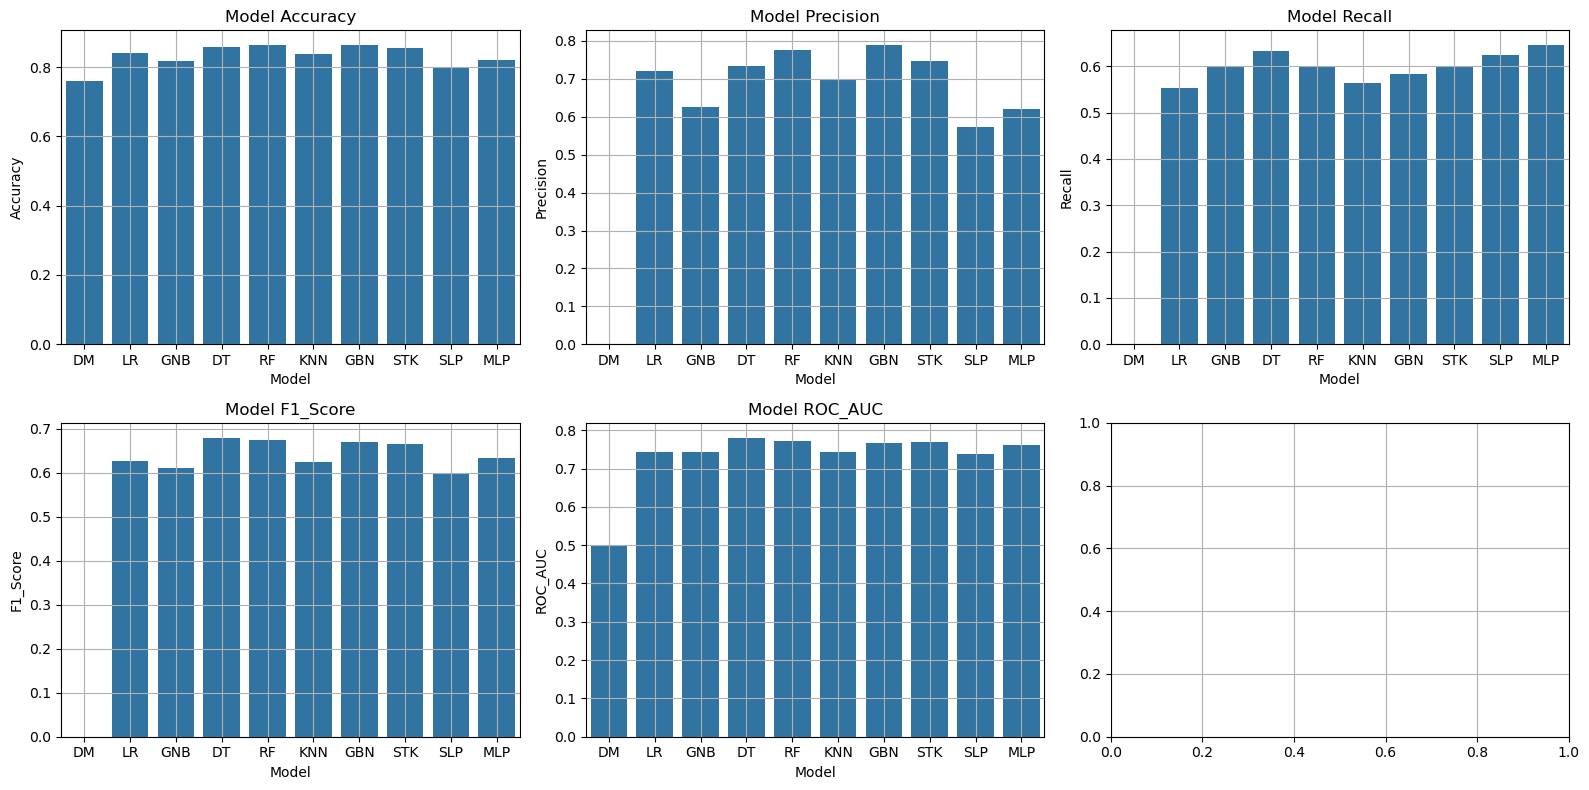

In [122]:
fig, ax = plt.subplots(2,3,figsize= (16,8))
sns.barplot(data = models, x = "Model", y = "Accuracy", ax=ax[0,0])
sns.barplot(data = models, x = "Model", y = "Precision", ax=ax[0,1])
sns.barplot(data = models, x = "Model", y = "Recall", ax=ax[0,2])
sns.barplot(data = models, x = "Model", y = "F1_Score", ax=ax[1,0])
sns.barplot(data = models, x = "Model", y = "ROC_AUC", ax=ax[1,1])
ax[0,0].set_title("Model Accuracy")
ax[0,1].set_title("Model Precision")
ax[0,2].set_title("Model Recall")
ax[1,0].set_title("Model F1_Score")
ax[1,1].set_title("Model ROC_AUC")
# Apply grid to every subplot
for axes in ax.flat:
    axes.grid(True)

plt.tight_layout()
plt.show()